RNN with all 80 leaf positions

In [2]:
import os
from field import Field
import pandas as pd
import numpy as np

In [3]:
def field_dimension(file_name):
    """
    imports the field information from the file name

    ------------------------------------------------
    Parameters
        file_name (str) - the name of the file to import from

    Returns
        field_info (dict) - the information for the field

    """
    import json

    if not isinstance(file_name, str):
        print("Error __import_field: file_name must be a string")

    if not file_name.endswith(".json"):
        print("Error __import_field: make sure file is json format")

    with open(file_name, "r") as f:
        field_info = json.load(f)

    cp = field_info["mqControlPoints"]

    m = len(cp)
    active_leaf_start = int(cp[0]["mlcLeaves"]//2 - cp[0]["collimatorX1"]/0.5) # first leaf outside jaw
    active_leaf_end = int(cp[0]["mlcLeaves"]//2 + cp[0]["collimatorX2"]/0.5)

    n = active_leaf_end - active_leaf_start + 1
        
    return (n,m)

In [48]:
# determine the max dimensions of a matrix

# we know the max dimensions will be 80x180

# max_n = 0
# max_m = 0

# features = [] # list for storing matrices
# AD = [] # list for storing AD

# dates = "C:\\Users\\gfman\\Documents\\RadiationData" # folder that contains all radiation fields

# for date in os.listdir(dates): # iterate through each day of saved data

#     files = dates + "/" + date # folder that contains all the fields for a select day

#     metadata = pd.read_json(files + "/" + os.listdir(files)[-1]).set_index("FieldID") # read the metadata of the daily files

#     for file in os.listdir(files): # iterate over every file from the day
#         if "MetaData" in file:
#             continue
#         filename = files + "/" + file # create file name

#         try:
#             dimensions = field_dimension(filename) # try to make a Field object from the radiation field

#         except:
#             continue

#         if dimensions[0] > max_n:
#             max_n =  dimensions[0]
#         if dimensions[1] > max_m:
#             max_m=  dimensions[1]


In [4]:
def pad_dataframe(existing_df, n, m):
    # Create a new matrix of size nxm filled with zeros
    padded_df = pd.DataFrame(0, index=range(n), columns=range(m), dtype="float64")
    
    # Determine the size of the existing dataframe
    p = existing_df.shape[0]
    q = existing_df.shape[1]
    
    # Copy the values from the existing dataframe to the padded matrix
    # Note: This will copy the values to the top-left corner of the padded matrix
    padded_df.iloc[:p, :q] = existing_df.iloc[:p, :q]
    
    return padded_df

In [5]:
class Field():

    def __init__(self, file_name):

        self.file = file_name
        field_info = self.__import_field(file_name)
        self.field_ID = field_info["fieldId"]
        self.name = field_info["name"]
        self.description = field_info["description"]
        self.machine_type = field_info["machineType"]
        self.machine_name = field_info["machineName"]
        self.type = field_info["type"]
        self.mq_type = field_info["mqType"]
        self.isocentre = field_info["isocentre"]
        self.beam_meterset = field_info["beamMeterset"]
        self.mq_control_points = field_info["mqControlPoints"]
        self.beam_energy = field_info["beamEnergy"]
        self.is_fff = field_info["isFff"]
        self.bolus_status = field_info["bolusStatus"]
        self.has_bolus = field_info["hasBolus"]
        self.__create_matrix()
    
    def __import_field(self, file_name):
        """
        imports the field information from the file name

        ------------------------------------------------
        Parameters
            file_name (str) - the name of the file to import from

        Returns
            field_info (dict) - the information for the field

        """
        import json

        if not isinstance(file_name, str):
            print("Error __import_field: file_name must be a string")

        if not file_name.endswith(".json"):
            print("Error __import_field: make sure file is json format")

        with open(file_name, "r") as f:
            field_info = json.load(f)

        return field_info

    
    def __create_matrix(self):
        """
        converts the field information from dictionairy for to a matrix with
        gantry angles indexing the columns and leaf numbers indexing the rows. 
        Adds the matrices to the field object.

        ---------------------------------------------------------------------
        Attributes
            None
        Returns 
            None
        """

        import pandas as pd
        import warnings

        matrixA = pd.DataFrame()
        matrixB = pd.DataFrame()

        index = []

        for segment in self.mq_control_points:
            index.append(segment["gantryAngle"])
            matrixA = pd.concat([matrixA, pd.Series(segment["leafSetA"])], axis = 1)
            matrixB = pd.concat([matrixB, pd.Series(segment["leafSetB"])], axis = 1)


        self.columns = index
        matrixA.columns = index
        matrixB.columns = index
        self.matrixA = matrixA
        self.matrixB = matrixB

        return

        

In [6]:
# 3D Tensor

features = [] # list for storing matrices
AD = [] # list for storing AD

dates = "C:\\Users\\gfman\\Documents\\RadiationData" # folder that contains all radiation fields

for date in os.listdir(dates): # iterate through each day of saved data

    files = dates + "/" + date # folder that contains all the fields for a select day

    metadata = pd.read_json(files + "/" + os.listdir(files)[-1]).set_index("FieldID") # read the metadata of the daily files

    for file in os.listdir(files): # iterate over every file from the day
        if "MetaData" in file:
            continue
        filename = files + "/" + file # create file name

        try:
            field = Field(filename) # try to make a Field object from the radiation field

        except:
            continue
        paddedA = pad_dataframe(field.matrixA, 80, 180)
        paddedB = pad_dataframe(field.matrixB, 80, 180)
        
        field_features = []
        for col in paddedA.columns:
            field_features.append(np.dstack((paddedA[col].values,paddedB[col].values)).flatten())

        features.append(field_features)
        
        AD.append(metadata.loc[field.field_ID, "AD"]<metadata.loc[field.field_ID, "ADPass"]) # append AD from metadata to list

Error __import_field: make sure file is json format


In [6]:
# 4D Tensor

# features = [] # list for storing matrices
# AD = [] # list for storing AD

# dates = "C:\\Users\\gfman\\Documents\\RadiationData" # folder that contains all radiation fields

# for date in os.listdir(dates): # iterate through each day of saved data

#     files = dates + "/" + date # folder that contains all the fields for a select day

#     metadata = pd.read_json(files + "/" + os.listdir(files)[-1]).set_index("FieldID") # read the metadata of the daily files

#     for file in os.listdir(files): # iterate over every file from the day

#         filename = files + "/" + file # create file name

#         try:
#             field = Field(filename) # try to make a Field object from the radiation field

#         except:
#             continue
#         paddedA = pad_dataframe(field.matrixA, max_n, max_m)
#         paddedB = pad_dataframe(field.matrixB, max_n, max_m)
        
#         field_features = []
#         for col in paddedA.columns:
#             field_features.append([paddedA[col], paddedB[col]])

#         features.append(field_features)
        
#         AD.append(metadata.loc[field.field_ID, "AD"]) # append AD from metadata to list

In [7]:
features = np.array(features)
AD = np.array(AD)

In [8]:
features.shape

(1464, 180, 160)

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(features, AD, test_size= 0.25)


In [10]:
from keras.models import Sequential
from keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=X_train.shape[1:]))
model.add(LSTM(units=50))
model.add(Dense(units=1, activation = 'sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics = ["accuracy"])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/10


c:\Users\gfman\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 149ms/step - accuracy: 0.8003 - loss: 0.5074 - val_accuracy: 0.8907 - val_loss: 0.3304
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 148ms/step - accuracy: 0.8961 - loss: 0.3024 - val_accuracy: 0.8907 - val_loss: 0.3035
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 161ms/step - accuracy: 0.8857 - loss: 0.2997 - val_accuracy: 0.8907 - val_loss: 0.2988
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 140ms/step - accuracy: 0.9078 - loss: 0.2599 - val_accuracy: 0.8962 - val_loss: 0.2633
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 138ms/step - accuracy: 0.9082 - loss: 0.2447 - val_accuracy: 0.8934 - val_loss: 0.2876
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - accuracy: 0.9123 - loss: 0.2566 - val_accuracy: 0.9044 - val_loss: 0.2662
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - accuracy: 0.9214 - loss: 0.2129 - val_accuracy: 0.9098 - val_loss: 0.2650
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 140ms/step - accuracy: 0.9284 - loss: 0.1894 - val_accuracy: 0.9016 - val_

In [11]:
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step
Training ROC AUC 0.8448057553956835


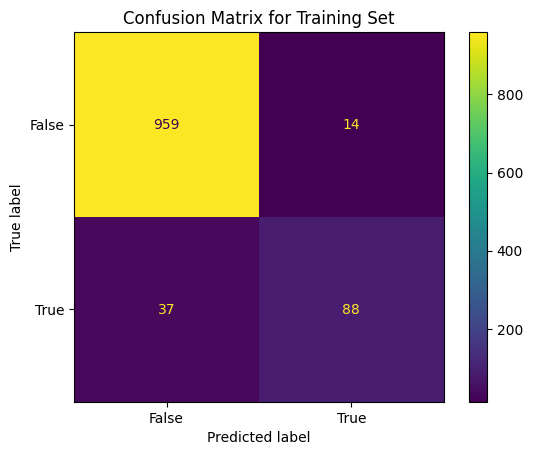

In [12]:
preds = model.predict(X_train)
print("Training ROC AUC", roc_auc_score(y_train, preds>0.5))
cm1 = ConfusionMatrixDisplay.from_predictions(y_train, preds>0.5)
cm1.ax_.set_title("Confusion Matrix for Training Set")
plt.show()

In [50]:
pd.Series(y_train).to_csv("RNN2_true.csv")

## ROC Curve

In [ ]:
import sklearn.metrics as metrics
# calculate the fpr and tpr for all thresholds of the classification
fpr, tpr, threshold = metrics.roc_curve(y_train2, preds_rnn2)
roc_auc = metrics.auc(fpr, tpr)

# method I: plt
import matplotlib.pyplot as plt
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()


In [ ]:
r_df = pd.read_csv("df.csv")
preds_lm = r_df["preds"]
lm_true = r_df["QAPass"]
preds_rnn1 = pd.read_csv("RNN2_preds.csv")["0"]
rnn1_true = pd.read_csv("RNN2_true.csv")['0']

In [ ]:
fpr_rf, tpr_rf, threshold = metrics.roc_curve(y_train, pred_rf)
roc_auc_rf = metrics.auc(fpr_rf, tpr_rf)

fpr_boosting, tpr_boosting, threshold = metrics.roc_curve(y_train, pred_boosting)
roc_auc_boosting = metrics.auc(fpr_boosting, tpr_boosting)

fpr_lm, tpr_lm, threshold = metrics.roc_curve(lm_true, preds_lm)
roc_auc_lm = metrics.auc(fpr_lm, tpr_lm)

fpr_rnn1, tpr_rnn1, threshold = metrics.roc_curve(rnn1_true, preds_rnn1)
roc_auc_rnn1 = metrics.auc(fpr_rnn1, tpr_rnn1)

fpr_rnn2, tpr_rnn2, threshold = metrics.roc_curve(y_test2, preds_rnn2)
roc_auc_rnn2 = metrics.auc(fpr_rnn2, tpr_rnn2)

plt.title('Receiver Operating Characteristic')
plt.plot(fpr_lm, tpr_lm, label = 'GLM AUC = %0.2f' % roc_auc_lm)
plt.plot(fpr_rf, tpr_rf, label = 'Random Forest AUC = %0.2f' % roc_auc_rf)
plt.plot(fpr_boosting, tpr_boosting, label = 'Boosting AUC = %0.2f' % roc_auc_boosting)
plt.plot(fpr_rnn1, tpr_rnn1, label = 'RNN 1 AUC = %0.2f' % roc_auc_rnn1)
plt.plot(fpr_rnn2, tpr_rnn2, label = 'RNN 2 AUC = %0.2f' % roc_auc_rnn2)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()